# Momentum126 Portfolio Construction

## Objective

Convert the strongest factor discovered in Notebook 02 into an investable portfolio.

Research Findings from Factor Zoo:

- Momentum126 produced the highest IC
- Momentum126 produced the highest Top-Bottom Spread
- Optimal portfolio size was 10–20 stocks

This notebook tests whether Momentum126 can generate superior portfolio performance through systematic rebalancing.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

close = pd.read_pickle(
    "../data/nifty500_close_clean.pkl"
)

print(close.shape)

(2716, 332)


In [3]:
mom126 = (
    close
    .pct_change(126)
    .shift(1)
)

rebalance_dates = close.index[126::63]

print(
    "Number of Rebalances:",
    len(rebalance_dates)
)

rebalance_dates[:5]

Number of Rebalances: 42


DatetimeIndex(['2015-07-07', '2015-10-07', '2016-01-11', '2016-04-13',
               '2016-07-15'],
              dtype='datetime64[s]', name='Date', freq=None)

In [4]:
portfolio_returns = []

for i in range(len(rebalance_dates)-1):

    start = rebalance_dates[i]
    end = rebalance_dates[i+1]

    scores = mom126.loc[start]

    top10 = (
        scores
        .dropna()
        .nlargest(10)
        .index
    )

    period_return = (
        close.loc[end, top10]
        /
        close.loc[start, top10]
        - 1
    ).mean()

    portfolio_returns.append(
        period_return
    )

In [5]:
portfolio_returns = pd.Series(
    portfolio_returns,
    index=rebalance_dates[:-1]
)

portfolio_returns.head()

Date
2015-07-07         NaN
2015-10-07   -0.021671
2016-01-11   -0.020114
2016-04-13    0.226718
2016-07-15    0.143468
dtype: float64

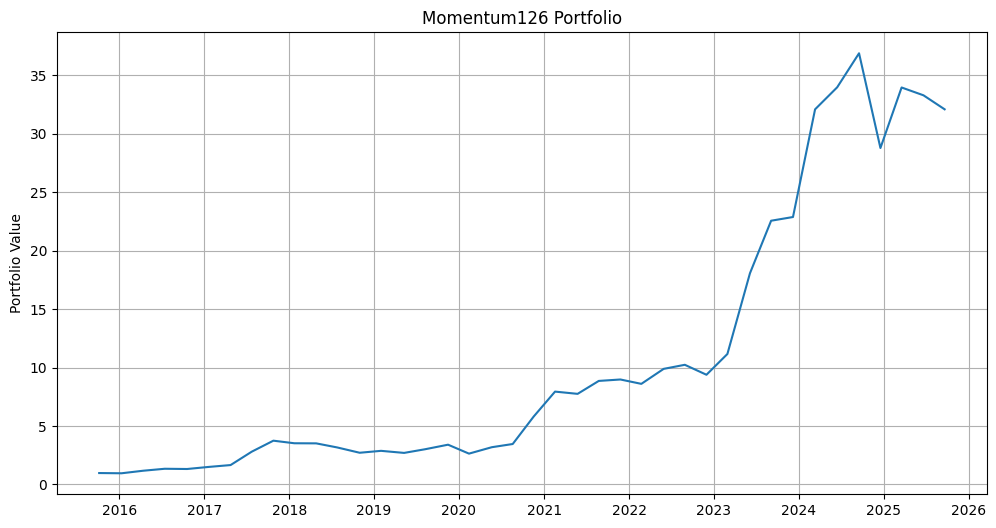

In [6]:
equity = (
    1 + portfolio_returns
).cumprod()

plt.figure(figsize=(12,6))

plt.plot(equity)

plt.title(
    "Momentum126 Portfolio"
)

plt.ylabel(
    "Portfolio Value"
)

plt.grid(True)

plt.show()

In [7]:
benchmark = (
    close.mean(axis=1)
)

benchmark = (
    benchmark
    / benchmark.iloc[0]
)

benchmark = benchmark.loc[equity.index]

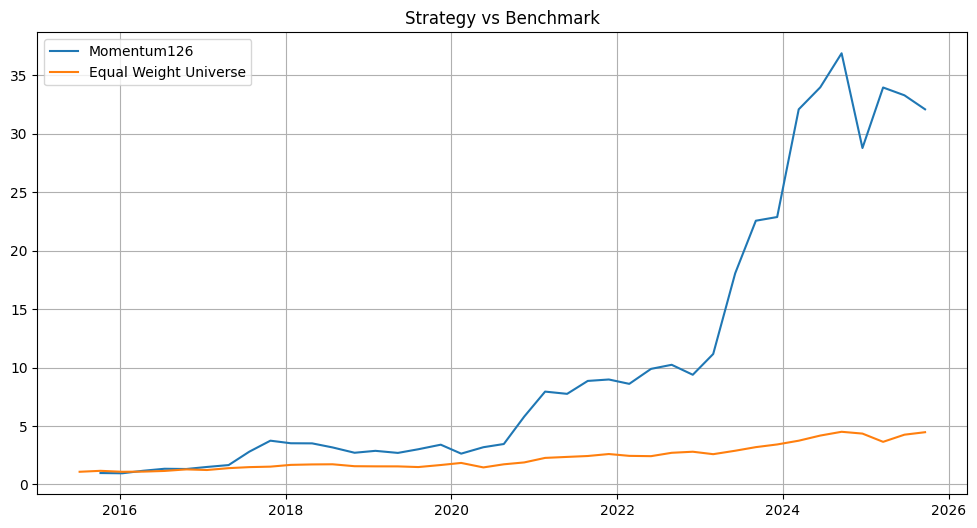

In [8]:
plt.figure(figsize=(12,6))

plt.plot(
    equity,
    label="Momentum126"
)

plt.plot(
    benchmark,
    label="Equal Weight Universe"
)

plt.legend()

plt.title(
    "Strategy vs Benchmark"
)

plt.grid(True)

plt.show()

In [9]:
cagr = (
    equity.iloc[-1]
    **
    (
        252 /
        len(close)
    )
    - 1
)

sharpe = (
    portfolio_returns.mean()
    /
    portfolio_returns.std()
) * np.sqrt(252/63)

max_dd = (
    equity
    /
    equity.cummax()
    - 1
).min()

print(
    f"Total Return: {(equity.iloc[-1]-1):.2%}"
)

print(
    f"CAGR: {cagr:.2%}"
)

print(
    f"Sharpe: {sharpe:.2f}"
)

print(
    f"Max Drawdown: {max_dd:.2%}"
)

Total Return: 3108.64%
CAGR: 37.96%
Sharpe: 1.02
Max Drawdown: -29.56%


In [10]:
weighted_returns = []

for i in range(len(rebalance_dates)-1):

    start = rebalance_dates[i]
    end = rebalance_dates[i+1]

    scores = (
        mom126.loc[start]
        .dropna()
        .nlargest(10)
    )

    weights = (
        scores / scores.sum()
    )

    stock_returns = (
        close.loc[end, scores.index]
        /
        close.loc[start, scores.index]
        - 1
    )

    portfolio_return = (
        weights * stock_returns
    ).sum()

    weighted_returns.append(
        portfolio_return
    )

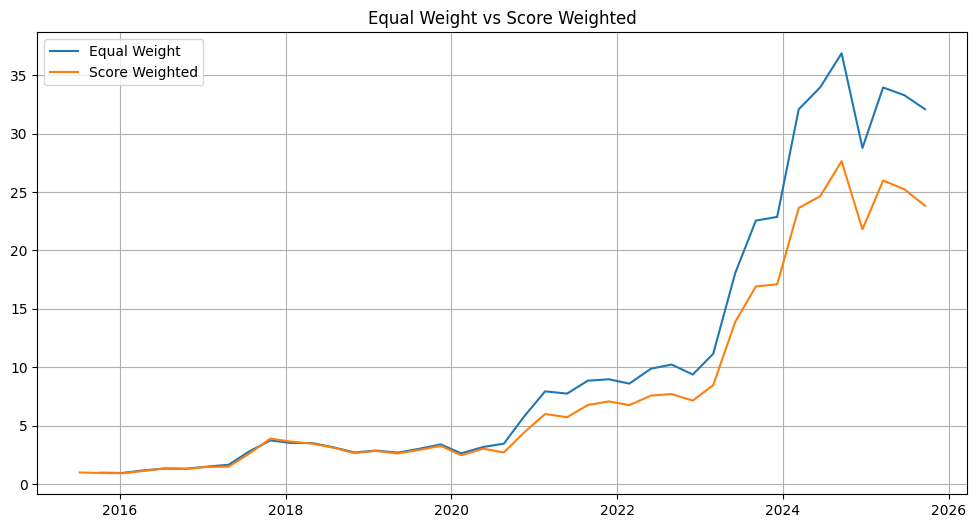

In [11]:
weighted_returns = pd.Series(
    weighted_returns,
    index=rebalance_dates[:-1]
)

weighted_equity = (
    1 + weighted_returns
).cumprod()

plt.figure(figsize=(12,6))

plt.plot(
    equity,
    label="Equal Weight"
)

plt.plot(
    weighted_equity,
    label="Score Weighted"
)

plt.legend()

plt.title(
    "Equal Weight vs Score Weighted"
)

plt.grid(True)

plt.savefig(
    "../results/plots/03_strategy_vs_benchmarkh.png",
    bbox_inches="tight"
)

plt.show()

In [12]:
cagr = (
    weighted_equity.iloc[-1]
    **
    (252 / len(close))
    - 1
)

sharpe = (
    weighted_returns.mean()
    /
    weighted_returns.std()
) * np.sqrt(252/63)

max_dd = (
    weighted_equity
    /
    weighted_equity.cummax()
    - 1
).min()

print(
    f"Total Return: {(weighted_equity.iloc[-1]-1):.2%}"
)

print(
    f"CAGR: {cagr:.2%}"
)

print(
    f"Sharpe: {sharpe:.2f}"
)

print(
    f"Max Drawdown: {max_dd:.2%}"
)

Total Return: 2283.09%
CAGR: 34.21%
Sharpe: 0.89
Max Drawdown: -36.50%


In [13]:
def backtest_momentum(top_n):

    portfolio_returns = []

    for i in range(len(rebalance_dates)-1):

        start = rebalance_dates[i]
        end = rebalance_dates[i+1]

        scores = mom126.loc[start]

        selected = (
            scores
            .dropna()
            .nlargest(top_n)
            .index
        )

        period_return = (
            close.loc[end, selected]
            /
            close.loc[start, selected]
            - 1
        ).mean()

        portfolio_returns.append(period_return)

    portfolio_returns = pd.Series(
        portfolio_returns,
        index=rebalance_dates[:-1]
    )

    equity = (1 + portfolio_returns).cumprod()

    cagr = (
        equity.iloc[-1] **
        (252 / len(close))
        - 1
    )

    sharpe = (
        portfolio_returns.mean()
        /
        portfolio_returns.std()
    ) * np.sqrt(252/63)

    return {
        "Total Return": equity.iloc[-1] - 1,
        "CAGR": cagr,
        "Sharpe": sharpe
    }

In [14]:
results = pd.DataFrame({
    "Top5": backtest_momentum(5),
    "Top10": backtest_momentum(10),
    "Top20": backtest_momentum(20),
    "Top30": backtest_momentum(30)
}).T

results

,Total Return,CAGR,Sharpe
Top5,36.415810,0.399438,0.923021
Top10,31.086447,0.379627,1.019187
Top20,29.238712,0.372056,1.174427
Top30,23.589508,0.345980,1.199790


In [15]:
metrics_df = pd.DataFrame({
    "Metric":[
        "Total Return",
        "CAGR",
        "Sharpe",
        "Max Drawdown"
    ],
    "Value":[
       equity.iloc[-1] - 1,
        cagr,
        sharpe,
        max_dd
    ]
})

metrics_df

metrics_df.to_csv(
    "../results/tables/03_final_metrics.csv",
    index=False
)

results.to_csv(
    "../results/tables/03_topn_comparison.csv"
)

## Portfolio Size Robustness

Results:

| Portfolio | CAGR | Sharpe |
|------------|------------|------------|
| Top 5 | 39.9% | 0.92 |
| Top 10 | 38.0% | 1.02 |
| Top 20 | 37.2% | 1.17 |
| Top 30 | 34.6% | 1.20 |

Findings:

- Returns decrease gradually as portfolio size increases.
- Risk-adjusted performance improves with diversification.
- Top 20 provides a strong balance between return and Sharpe ratio.
- Momentum126 remains effective across multiple portfolio sizes, demonstrating robustness.